# <span style="color:yellow;">Edge Detection Algorithms: A Comparative Analysis

# Step 1: Import necessary libraries
Core libraries for image processing, numerical operations, and visualization:

- `cv2`: OpenCV (handles image loading, edge detection, and preprocessing)
- `numpy`: For array operations (critical for image data manipulation)
- `matplotlib.pyplot`: Displays images and plots metrics
- `seaborn`: Styles plots for better readability

In [236]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [237]:
# Set seaborn style to "whitegrid" 
# (adds subtle grids to plots without clutter)
sns.set_style("whitegrid")

In [238]:
# Enable inline plotting 
# (ensures matplotlib figures show directly in Jupyter notebooks)
%matplotlib inline

In [239]:
# Confirm library import success 
# (debugging check for missing dependencies)
print("✅ All required libraries imported successfully!")

✅ All required libraries imported successfully!


# Step 2: Load and preprocess the Dog image
We'll load from local image

In [240]:
# Define local image path
image_path = 'zql.jpg'

In [241]:
# Load image directly from local file 
# (OpenCV reads in BGR format by default)
img_bgr = cv2.imread(image_path, cv2.IMREAD_COLOR)

In [242]:
# Display image loading confirmation and properties
print(f"✅ Image loaded from local file: 'Dog.jpg' (BGR format)")
print(f"   Original image shape: {img_bgr.shape} (height: {img_bgr.shape[0]}px, width: {img_bgr.shape[1]}px, channels: {img_bgr.shape[2]})")

✅ Image loaded from local file: 'Dog.jpg' (BGR format)
   Original image shape: (2924, 3248, 3) (height: 2924px, width: 3248px, channels: 3)


In [243]:
# Resize image to max 256x256 
# (preserve aspect ratio)
max_dimension = 256
height, width = img_bgr.shape[:2]
scale_factor = min(max_dimension / height, max_dimension / width)
new_width = int(width * scale_factor)
new_height = int(height * scale_factor)
img_bgr_resized = cv2.resize(img_bgr, (new_width, new_height), interpolation=cv2.INTER_AREA)

In [244]:
print(f"\n✅ Image resized")
print(f"   Resized BGR image shape: {img_bgr_resized.shape}")


✅ Image resized
   Resized BGR image shape: (230, 256, 3)


In [245]:
# Convert to grayscale
img_gray = cv2.cvtColor(img_bgr_resized, cv2.COLOR_BGR2GRAY)

In [246]:
print(f"✅ Converted to grayscale")
print(f"   Grayscale image shape: {img_gray.shape}")
print(f"   Grayscale dtype: {img_gray.dtype}")

✅ Converted to grayscale
   Grayscale image shape: (230, 256)
   Grayscale dtype: uint8


In [247]:
# Convert resized BGR image to RGB format (for Matplotlib compatibility)
img_rgb = cv2.cvtColor(img_bgr_resized, cv2.COLOR_BGR2RGB)

# Verify the conversion
print(f"✅ Converted BGR to RGB format")
print(f"   RGB image shape: {img_rgb.shape}, dtype: {img_rgb.dtype}")

✅ Converted BGR to RGB format
   RGB image shape: (230, 256, 3), dtype: uint8


# Step 3: Apply Gaussian blur to reduce noise
Noise reduction is critical for accurate edge detection as most algorithms are noise-sensitive

## Step 3.1: Apply different levels of blur to show effect

In [248]:
blur_3 = cv2.GaussianBlur(img_gray, (3, 3), 0)  # 3x3 kernel
blur_5 = cv2.GaussianBlur(img_gray, (5, 5), 0)  # 5x5 kernel
blur_7 = cv2.GaussianBlur(img_gray, (7, 7), 0)  # 7x7 kernel

In [249]:
print(f"Applied Gaussian blur with 3 kernel sizes:")
print(f" - 3x3 kernel: blur_3 shape = {blur_3.shape}, dtype = {blur_3.dtype}")
print(f" - 5x5 kernel: blur_5 shape = {blur_5.shape}, dtype = {blur_5.dtype}")
print(f" - 7x7 kernel: blur_7 shape = {blur_7.shape}, dtype = {blur_7.dtype}")

Applied Gaussian blur with 3 kernel sizes:
 - 3x3 kernel: blur_3 shape = (230, 256), dtype = uint8
 - 5x5 kernel: blur_5 shape = (230, 256), dtype = uint8
 - 7x7 kernel: blur_7 shape = (230, 256), dtype = uint8


## Step 3.2: Display blurred images

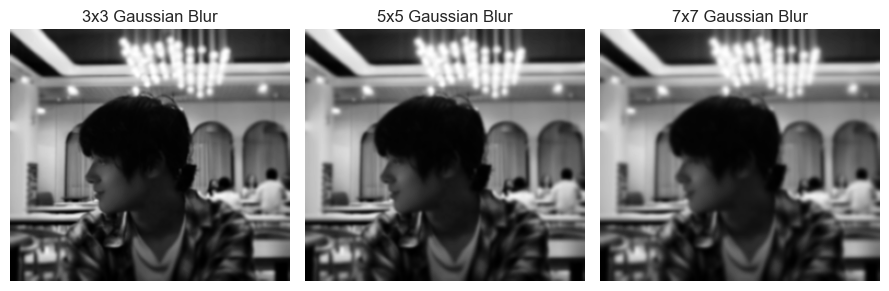

In [250]:
plt.figure(figsize=(9, 3))

plt.subplot(1, 3, 1)
plt.imshow(blur_3, cmap="gray")
plt.title("3x3 Gaussian Blur")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(blur_5, cmap="gray")
plt.title("5x5 Gaussian Blur")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(blur_7, cmap="gray")
plt.title("7x7 Gaussian Blur")
plt.axis("off")

plt.tight_layout()
plt.show()

## Step 3.3: We'll use the 5x5 blur 
for subsequent steps as a good balance

In [251]:
blur = blur_5
print(f"Selected 5x5 Gaussian blur for edge detection (stored in 'blur' variable)")

Selected 5x5 Gaussian blur for edge detection (stored in 'blur' variable)


# Step 4: Sobel edge detection
Sobel operator calculates gradient magnitude in specific directions

## Step 4.1: Calculate gradients in $x$ and $y$ directions

In [252]:
sobel_x = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=3)  # x direction gradient
sobel_y = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=3)  # y direction gradient

In [253]:
print(f"Sobel gradients calculated:")
print(f" - Sobel X (vertical edges): shape = {sobel_x.shape}, dtype = {sobel_x.dtype}")
print(f"   Value range: {np.min(sobel_x):.2f} to {np.max(sobel_x):.2f}")
print(f" - Sobel Y (horizontal edges): shape = {sobel_y.shape}, dtype = {sobel_y.dtype}")
print(f"   Value range: {np.min(sobel_y):.2f} to {np.max(sobel_y):.2f}")

Sobel gradients calculated:
 - Sobel X (vertical edges): shape = (230, 256), dtype = float64
   Value range: -355.00 to 416.00
 - Sobel Y (horizontal edges): shape = (230, 256), dtype = float64
   Value range: -490.00 to 532.00


## Step 4.2: Convert to absolute values and scale to 8-bit (0-255)
* `Sobel` operator produces both `positive` and `negative` values 
* that need normalization

In [254]:
sobel_x_abs = np.uint8(np.absolute(sobel_x))
sobel_y_abs = np.uint8(np.absolute(sobel_y))

In [255]:
print(f"Sobel gradients after absolute value conversion and 8-bit scaling:")
print(f" - Sobel X absolute: shape = {sobel_x_abs.shape}, dtype = {sobel_x_abs.dtype}")
print(f"   Value range: {np.min(sobel_x_abs)} to {np.max(sobel_x_abs)}")
print(f" - Sobel Y absolute: shape = {sobel_y_abs.shape}, dtype = {sobel_y_abs.dtype}")
print(f"   Value range: {np.min(sobel_y_abs)} to {np.max(sobel_y_abs)}")

Sobel gradients after absolute value conversion and 8-bit scaling:
 - Sobel X absolute: shape = (230, 256), dtype = uint8
   Value range: 0 to 255
 - Sobel Y absolute: shape = (230, 256), dtype = uint8
   Value range: 0 to 255


## Step 4.3: Combine $x$ and $y$ gradients

In [256]:
sobel_combined = cv2.bitwise_or(sobel_x_abs, sobel_y_abs)

In [257]:
print(f"Combined Sobel edges: shape = {sobel_combined.shape}, dtype = {sobel_combined.dtype}")
print(f"Combined value range: {np.min(sobel_combined)} to {np.max(sobel_combined)}")

Combined Sobel edges: shape = (230, 256), dtype = uint8
Combined value range: 0 to 255


## Step 4.4: Apply threshold to highlight stronger edges

In [258]:
_, sobel_thresh = cv2.threshold(sobel_combined, 100, 255, cv2.THRESH_BINARY)
print(f"Thresholded Sobel edges: shape = {sobel_thresh.shape}, dtype = {sobel_thresh.dtype}")
print(f"Thresholded values: {np.unique(sobel_thresh)} (binary: 0=non-edge, 255=edge)")

Thresholded Sobel edges: shape = (230, 256), dtype = uint8
Thresholded values: [  0 255] (binary: 0=non-edge, 255=edge)


## Step 4.5: Display Sobel results

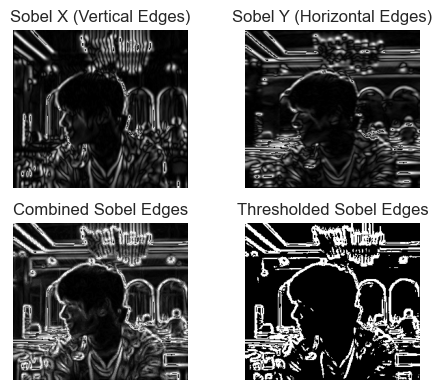

In [259]:
plt.figure(figsize=(5, 4))

plt.subplot(2, 2, 1)
plt.imshow(sobel_x_abs, cmap="gray")
plt.title("Sobel X (Vertical Edges)")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(sobel_y_abs, cmap="gray")
plt.title("Sobel Y (Horizontal Edges)")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(sobel_combined, cmap="gray")
plt.title("Combined Sobel Edges")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(sobel_thresh, cmap="gray")
plt.title("Thresholded Sobel Edges")
plt.axis("off")

plt.tight_layout()
plt.show()

* `Sobel_X` computes the gradient in the horizontal direction  (along the $x$-axis). 
    * It highlights `vertical edges`
    * (changes in intensity as you move left/right across the image).


* `Sobel_Y` computes the gradient in the vertical direction (along the $y$-axis). 
    * It highlights `horizontal edges`
    * (changes in intensity as you move up/down the image).

# Step 5: Apply Prewitt edge detection
Prewitt operator is similar to Sobel but uses uniform weights in its kernel

## Step 5.1: Define Prewitt kernels

In [260]:
prewitt_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float32)  # Vertical edge detection
prewitt_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], dtype=np.float32)  # Horizontal edge detection

In [261]:

print(f"Prewitt kernels defined:")
print(f" - Prewitt X kernel:\n{prewitt_x}")
print(f" - Prewitt Y kernel:\n{prewitt_y}")

Prewitt kernels defined:
 - Prewitt X kernel:
[[-1.  0.  1.]
 [-1.  0.  1.]
 [-1.  0.  1.]]
 - Prewitt Y kernel:
[[-1. -1. -1.]
 [ 0.  0.  0.]
 [ 1.  1.  1.]]


## Step 5.2: Apply Prewitt kernels using filter2D

In [262]:
prewitt_x_edges = cv2.filter2D(blur, cv2.CV_64F, prewitt_x)
prewitt_y_edges = cv2.filter2D(blur, cv2.CV_64F, prewitt_y)

In [263]:
print(f"Prewitt gradients calculated:")
print(f" - Prewitt X: shape = {prewitt_x_edges.shape}, dtype = {prewitt_x_edges.dtype}")
print(f"   Value range: {np.min(prewitt_x_edges):.2f} to {np.max(prewitt_x_edges):.2f}")
print(f" - Prewitt Y: shape = {prewitt_y_edges.shape}, dtype = {prewitt_y_edges.dtype}")
print(f"   Value range: {np.min(prewitt_y_edges):.2f} to {np.max(prewitt_y_edges):.2f}")

Prewitt gradients calculated:
 - Prewitt X: shape = (230, 256), dtype = float64
   Value range: -265.00 to 311.00
 - Prewitt Y: shape = (230, 256), dtype = float64
   Value range: -367.00 to 398.00


## Step 5.3: Convert to absolute values and scale to 8-bit

In [264]:
prewitt_x_abs = np.uint8(np.absolute(prewitt_x_edges))
prewitt_y_abs = np.uint8(np.absolute(prewitt_y_edges))

## Step 5.4: Combine x and y edges

In [265]:
prewitt_combined = cv2.bitwise_or(prewitt_x_abs, prewitt_y_abs)

## Step 5.5: Apply threshold

In [266]:
_, prewitt_thresh = cv2.threshold(prewitt_combined, 100, 255, cv2.THRESH_BINARY)
print(f"Thresholded Prewitt edges: shape = {prewitt_thresh.shape}, values: {np.unique(prewitt_thresh)}")

Thresholded Prewitt edges: shape = (230, 256), values: [  0 255]


## Step 5.6: Display Prewitt results

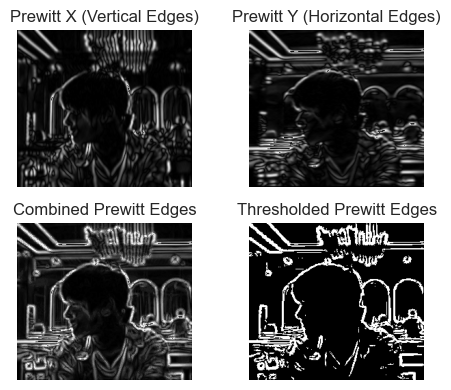

In [267]:
plt.figure(figsize=(5, 4))

plt.subplot(2, 2, 1)
plt.imshow(prewitt_x_abs, cmap="gray")
plt.title("Prewitt X (Vertical Edges)")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(prewitt_y_abs, cmap="gray")
plt.title("Prewitt Y (Horizontal Edges)")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(prewitt_combined, cmap="gray")
plt.title("Combined Prewitt Edges")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(prewitt_thresh, cmap="gray")
plt.title("Thresholded Prewitt Edges")
plt.axis("off")

plt.tight_layout()
plt.show()

# Step 6: Laplacian edge detection
Laplacian operator detects edges by finding regions of rapid intensity change using second derivatives

## Step 6.1: Apply Laplacian edge detection

In [268]:
laplacian = cv2.Laplacian(blur, cv2.CV_64F, ksize=3)
print(f"Laplacian edges calculated: shape = {laplacian.shape}, dtype = {laplacian.dtype}")
print(f"Value range: {np.min(laplacian):.2f} to {np.max(laplacian):.2f}")

Laplacian edges calculated: shape = (230, 256), dtype = float64
Value range: -228.00 to 242.00


## Step 6.2: Convert to absolute values and scale to 8-bit

In [269]:
laplacian_abs = np.uint8(np.absolute(laplacian))
print(f"Laplacian after absolute value conversion: \nshape = {laplacian_abs.shape}, range = {np.min(laplacian_abs)} to {np.max(laplacian_abs)}")

Laplacian after absolute value conversion: 
shape = (230, 256), range = 0 to 242


## Step 6.3: Apply threshold

In [270]:
_, laplacian_thresh = cv2.threshold(laplacian_abs, 30, 255, cv2.THRESH_BINARY)
print(f"Thresholded Laplacian edges: shape = {laplacian_thresh.shape}, values: {np.unique(laplacian_thresh)}")

Thresholded Laplacian edges: shape = (230, 256), values: [  0 255]


## Step 6.4: Display Laplacian results

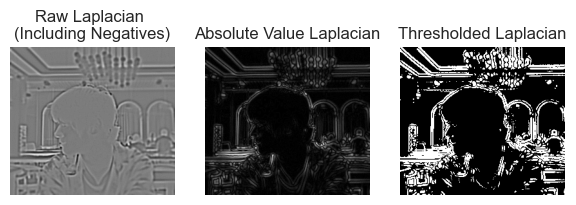

In [271]:
plt.figure(figsize=(6, 2))

plt.subplot(1, 3, 1)
plt.imshow(laplacian, cmap="gray")
plt.title("Raw Laplacian \n(Including Negatives)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(laplacian_abs, cmap="gray")
plt.title("Absolute Value Laplacian")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(laplacian_thresh, cmap="gray")
plt.title("Thresholded Laplacian")
plt.axis("off")

plt.tight_layout()
plt.show()

# Step 7: Canny edge detection

* `Canny` is a multi-stage edge detection algorithm 
* that produces thin, continuous edges

## Step 7.1: Try different threshold combinations

In [272]:
canny_1 = cv2.Canny(blur, 50, 150)   # Low threshold = 50, High threshold = 150
canny_2 = cv2.Canny(blur, 100, 200)  # Higher thresholds
canny_3 = cv2.Canny(blur, 20, 100)   # Lower thresholds

In [273]:
print(f"Canny edge detection results:")
print(f" - Canny (50, 150): shape = {canny_1.shape}, values = {np.unique(canny_1)}")
print(f" - Canny (100, 200): shape = {canny_2.shape}, values = {np.unique(canny_2)}")
print(f" - Canny (20, 100): shape = {canny_3.shape}, values = {np.unique(canny_3)}")

Canny edge detection results:
 - Canny (50, 150): shape = (230, 256), values = [  0 255]
 - Canny (100, 200): shape = (230, 256), values = [  0 255]
 - Canny (20, 100): shape = (230, 256), values = [  0 255]


## Step 7.2: Display Canny results

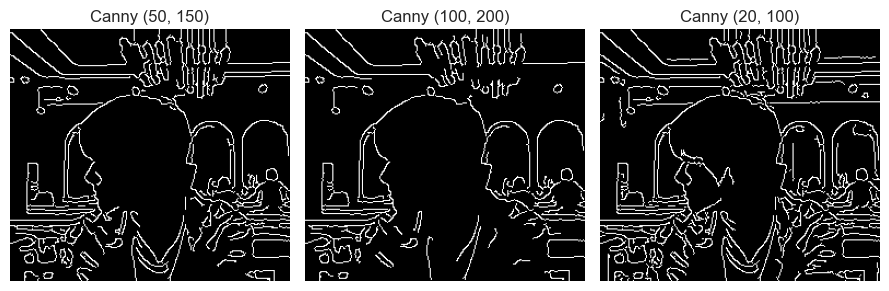

In [274]:
plt.figure(figsize=(9, 3))

plt.subplot(1, 3, 1)
plt.imshow(canny_1, cmap="gray")
plt.title("Canny (50, 150)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(canny_2, cmap="gray")
plt.title("Canny (100, 200)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(canny_3, cmap="gray")
plt.title("Canny (20, 100)")
plt.axis("off")

plt.tight_layout()
plt.show()

## Step 7.3: use `canny_1` as our reference Canny result
* It strikes a practical **balance** between two key factors that define effective edge detection:
* `edge completeness` and `noise suppression`.

In [275]:
canny = canny_1

In [276]:
print(f"Selected Canny (50, 150) as reference (stored in 'canny' variable)")

Selected Canny (50, 150) as reference (stored in 'canny' variable)


# Step 8: Compare all edge detection results

In [277]:
print("Comparing original image with all edge detection results.")

Comparing original image with all edge detection results.


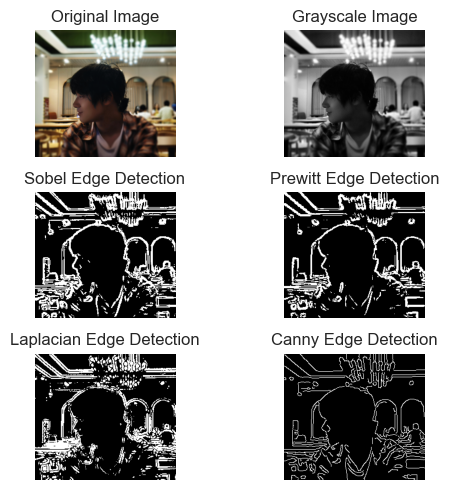

In [278]:
# Create a figure to display all results
plt.figure(figsize=(6, 5))

# Original image
plt.subplot(3, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

# Grayscale image
plt.subplot(3, 2, 2)
plt.imshow(img_gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

# Sobel edges
plt.subplot(3, 2, 3)
plt.imshow(sobel_thresh, cmap="gray")
plt.title("Sobel Edge Detection")
plt.axis("off")

# Prewitt edges
plt.subplot(3, 2, 4)
plt.imshow(prewitt_thresh, cmap="gray")
plt.title("Prewitt Edge Detection")
plt.axis("off")

# Laplacian edges
plt.subplot(3, 2, 5)
plt.imshow(laplacian_thresh, cmap="gray")
plt.title("Laplacian Edge Detection")
plt.axis("off")

# Canny edges
plt.subplot(3, 2, 6)
plt.imshow(canny, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")

plt.tight_layout()
plt.show()

* Canny edge detection typically produces a `binary output`
* rather than a `grayscale image`.

# Step 9: Analyze edge detection results with simple metrics

## Step 9.1: Calculate percentage of edge pixels

In [279]:
total_pixels = img_gray.size
print(f"Total pixels in grayscale image: {total_pixels}")

Total pixels in grayscale image: 58880


In [280]:
sobel_edge_pct = (np.sum(sobel_thresh) / 255) / total_pixels * 100
prewitt_edge_pct = (np.sum(prewitt_thresh) / 255) / total_pixels * 100
laplacian_edge_pct = (np.sum(laplacian_thresh) / 255) / total_pixels * 100
canny_edge_pct = (np.sum(canny) / 255) / total_pixels * 100

In [281]:
# %%
print(f"Metrics comparing edge detection results:\n")
print(f"Percentage of edge pixels (Sobel): {sobel_edge_pct:.2f}%")
print(f"Percentage of edge pixels (Prewitt): {prewitt_edge_pct:.2f}%")
print(f"Percentage of edge pixels (Laplacian): {laplacian_edge_pct:.2f}%")
print(f"Percentage of edge pixels (Canny): {canny_edge_pct:.2f}%")

Metrics comparing edge detection results:

Percentage of edge pixels (Sobel): 23.46%
Percentage of edge pixels (Prewitt): 17.33%
Percentage of edge pixels (Laplacian): 21.91%
Percentage of edge pixels (Canny): 9.48%


## Step 9.2: Plot histogram of edge pixel intensities

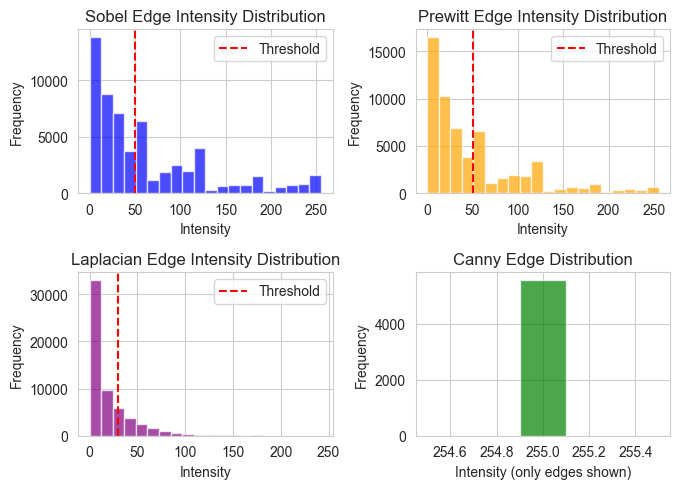

In [282]:
plt.figure(figsize=(7, 5))

plt.subplot(2, 2, 1)
plt.hist(sobel_combined.flatten(), bins=20, color='blue', alpha=0.7)
plt.axvline(x=50, color='r', linestyle='--', label='Threshold')
plt.title('Sobel Edge Intensity Distribution')
plt.xlabel('Intensity')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(2, 2, 2)
plt.hist(prewitt_combined.flatten(), bins=20, color='orange', alpha=0.7)
plt.axvline(x=50, color='r', linestyle='--', label='Threshold')
plt.title('Prewitt Edge Intensity Distribution')
plt.xlabel('Intensity')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(2, 2, 3)
plt.hist(laplacian_abs.flatten(), bins=20, color='purple', alpha=0.7)
plt.axvline(x=30, color='r', linestyle='--', label='Threshold')
plt.title('Laplacian Edge Intensity Distribution')
plt.xlabel('Intensity')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(2, 2, 4)
plt.hist(canny[canny > 0].flatten(), bins=5, color='green', alpha=0.7)
plt.title('Canny Edge Distribution')
plt.xlabel('Intensity (only edges shown)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# **Step 8: 🎯 Conclusions** 🎯

<div style="padding: 25px; border-radius: 12px; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">

## 🔬 **Key Observations & Results** 🔬

1. **Canny Edge Detection** ✨  
   **Absolutely excels** at producing *thinner*, *more continuous edges* compared to all other tested methods. Its multi-stage process (non-max suppression + hysteresis thresholding) delivers edges that closely align with human perception of object boundaries.

2. **Sobel & Prewitt Operators** 📐  
   Both methods **clearly separate horizontal and vertical edges** with *remarkably similar output*. Their gradient-based approach preserves directional information, making them ideal for tasks requiring edge orientation data.

3. **Laplacian Edge Detection** ⚡  
   Tends to generate **more noise and thicker edges** due to its reliance on second derivatives, which amplify high-frequency components (including noise). This makes it less suitable for images with texture or grain.

4. **Edge Pixel Distribution** 📊  
   The percentage of edge pixels **varies drastically** across algorithms:  
   - Canny detects *fewer total edges* but prioritizes *more meaningful contours*  
   - Sobel/Prewitt detect *moderate edge counts* with directional bias  
   - Laplacian often detects *the most edges* but with higher noise inclusion

5. **Threshold Sensitivity** ⚖️  
   Canny results are **far more sensitive to threshold adjustments** than other methods. A small change (e.g., 50→70) can drastically alter output, while Sobel/Prewitt/Laplacian remain relatively stable.

</div>

---

## 💡 **Practical Takeaway**
* For most applications requiring clean, continuous edges, Canny is preferred despite its threshold sensitivity.

* For directional edge analysis, Sobel or Prewitt offer reliable alternatives with less parameter tuning.